In [1]:
# Importação das bibliotecas iniciais

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminho local do projeto
PROJECT_PATH = r"E:\Projetos Data science\credit-risk-machine-learning"

# Caminhos das principais pastas
DATA_PATH = os.path.join(PROJECT_PATH, "data")
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "notebooks")
OUTPUTS_PATH = os.path.join(PROJECT_PATH, "outputs")

# Criar pastas caso ainda não existam
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(NOTEBOOKS_PATH, exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)

# Exibir os caminhos configurados
print("Caminho do projeto:", PROJECT_PATH)
print("Pasta de dados:", DATA_PATH)
print("Pasta de modelos:", MODELS_PATH)
print("Pasta de notebooks:", NOTEBOOKS_PATH)
print("Pasta de outputs:", OUTPUTS_PATH)

Caminho do projeto: E:\Projetos Data science\credit-risk-machine-learning
Pasta de dados: E:\Projetos Data science\credit-risk-machine-learning\data
Pasta de modelos: E:\Projetos Data science\credit-risk-machine-learning\models
Pasta de notebooks: E:\Projetos Data science\credit-risk-machine-learning\notebooks
Pasta de outputs: E:\Projetos Data science\credit-risk-machine-learning\outputs


In [2]:
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(NOTEBOOKS_PATH, exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)

## Criação do dataset inicial

Nesta primeira versão do projeto, será criado um dataset simulado de risco de crédito.

O objetivo é representar um cenário de análise de clientes, com variáveis financeiras e comportamentais que podem influenciar o risco de inadimplência.

As variáveis principais serão:

- idade
- renda mensal
- valor do empréstimo
- histórico de atraso
- score de crédito
- tempo de emprego
- quantidade de empréstimos anteriores
- inadimplente

A variável alvo será `inadimplente`, indicando se o cliente apresentou ou não inadimplência.

In [3]:
# Criando dataset simulado de risco de crédito

np.random.seed(42)

num_clientes = 1000

dados = {
    "idade": np.random.randint(18, 70, num_clientes),
    "renda_mensal": np.random.normal(5000, 2000, num_clientes).round(2),
    "valor_emprestimo": np.random.normal(15000, 7000, num_clientes).round(2),
    "historico_atraso": np.random.choice([0, 1], size=num_clientes, p=[0.75, 0.25]),
    "score_credito": np.random.randint(300, 900, num_clientes),
    "tempo_emprego_anos": np.random.randint(0, 30, num_clientes),
    "emprestimos_anteriores": np.random.randint(0, 8, num_clientes)
}

df = pd.DataFrame(dados)

# Corrigir valores negativos gerados pela distribuição normal
df["renda_mensal"] = df["renda_mensal"].clip(lower=1000)
df["valor_emprestimo"] = df["valor_emprestimo"].clip(lower=1000)

# Criar regra simulada de inadimplência
risco = (
    (df["historico_atraso"] * 0.35) +
    ((900 - df["score_credito"]) / 600 * 0.30) +
    ((df["valor_emprestimo"] / df["renda_mensal"]) > 4).astype(int) * 0.20 +
    ((df["tempo_emprego_anos"] < 2).astype(int) * 0.10) +
    (np.random.random(num_clientes) * 0.15)
)

df["inadimplente"] = (risco > 0.45).astype(int)

# Visualizar primeiras linhas
df.head()

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,inadimplente
0,56,1787.11,27088.75,0,382,1,4,1
1,69,5406.93,12202.55,0,409,19,6,0
2,46,3487.30,16572.79,1,489,19,2,1
3,32,2155.49,21528.14,0,550,26,5,0
4,60,3706.85,5071.44,1,590,13,5,1


## Salvamento do dataset

Após a criação do dataset inicial, os dados serão salvos em formato CSV na pasta `data`.

Isso permite que o projeto trabalhe com um arquivo local, simulando um fluxo mais próximo de um projeto real.

In [4]:
# Salvar o dataset na pasta data

arquivo_credito = os.path.join(DATA_PATH, "credit_risk_data.csv")

df.to_csv(arquivo_credito, index=False, encoding="utf-8-sig")

print("Dataset salvo com sucesso em:")
print(arquivo_credito)

Dataset salvo com sucesso em:
E:\Projetos Data science\credit-risk-machine-learning\data\credit_risk_data.csv


## Carregamento dos dados

A partir deste ponto, o projeto passa a carregar os dados a partir do arquivo CSV salvo anteriormente.

Esse fluxo ajuda a organizar melhor o projeto e facilita a publicação no GitHub.

In [5]:
# Carregar o dataset salvo

df = pd.read_csv(arquivo_credito)

# Visualizar primeiras linhas
df.head()

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,inadimplente
0,56,1787.11,27088.75,0,382,1,4,1
1,69,5406.93,12202.55,0,409,19,6,0
2,46,3487.30,16572.79,1,489,19,2,1
3,32,2155.49,21528.14,0,550,26,5,0
4,60,3706.85,5071.44,1,590,13,5,1


## Análise inicial dos dados

Nesta etapa, será feita uma visão geral da base de dados.

Serão verificados:

- quantidade de linhas e colunas
- tipos de dados
- valores ausentes
- estatísticas descritivas
- distribuição da variável alvo `inadimplente`

In [6]:
# Verificar tamanho da base

print("Quantidade de linhas e colunas:")
print(df.shape)

Quantidade de linhas e colunas:
(1000, 8)


In [7]:
# Verificar tipos de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idade                   1000 non-null   int64  
 1   renda_mensal            1000 non-null   float64
 2   valor_emprestimo        1000 non-null   float64
 3   historico_atraso        1000 non-null   int64  
 4   score_credito           1000 non-null   int64  
 5   tempo_emprego_anos      1000 non-null   int64  
 6   emprestimos_anteriores  1000 non-null   int64  
 7   inadimplente            1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [8]:
# Verificar valores ausentes

df.isnull().sum()

idade                     0
renda_mensal              0
valor_emprestimo          0
historico_atraso          0
score_credito             0
tempo_emprego_anos        0
emprestimos_anteriores    0
inadimplente              0
dtype: int64

In [9]:
# Estatísticas descritivas

df.describe()

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,inadimplente
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,5128.317470,15202.873140,0.244000,602.220000,14.317000,3.364000,0.324000
std,14.99103,1944.753435,6719.910631,0.429708,174.814089,8.517809,2.273472,0.468234
min,18.00000,1000.000000,1000.000000,0.000000,300.000000,0.000000,0.000000,0.000000
25%,31.00000,3776.325000,10509.620000,0.000000,446.750000,7.000000,1.000000,0.000000
50%,44.00000,5107.670000,15026.700000,0.000000,599.000000,14.000000,3.000000,0.000000
75%,56.00000,6370.937500,19789.800000,0.000000,758.000000,22.000000,5.000000,1.000000
max,69.00000,10264.760000,37351.750000,1.000000,899.000000,29.000000,7.000000,1.000000


In [10]:
# Distribuição da variável alvo

df["inadimplente"].value_counts()

inadimplente
0    676
1    324
Name: count, dtype: int64

In [11]:
# Distribuição percentual da variável alvo

df["inadimplente"].value_counts(normalize=True) * 100

inadimplente
0    67.6
1    32.4
Name: proportion, dtype: float64

### Interpretação inicial da variável alvo

A variável alvo do projeto é `inadimplente`.

Nesta base inicial, aproximadamente 67,6% dos clientes pertencem à classe 0, ou seja, não inadimplentes.

Já 32,4% pertencem à classe 1, representando clientes inadimplentes.

Existe um desbalanceamento moderado entre as classes, mas não é um caso extremo.

Mesmo assim, na avaliação dos modelos será importante observar métricas como precision, recall e f1-score, e não apenas acurácia.

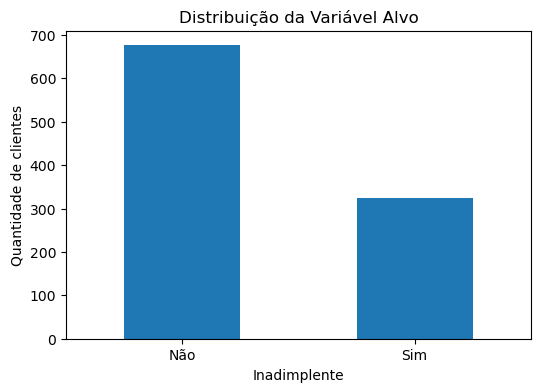

In [12]:
# Gráfico da distribuição da variável alvo

plt.figure(figsize=(6, 4))

df["inadimplente"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição da Variável Alvo")
plt.xlabel("Inadimplente")
plt.ylabel("Quantidade de clientes")
plt.xticks(ticks=[0, 1], labels=["Não", "Sim"], rotation=0)
plt.show()

## Análise exploratória das variáveis

Nesta etapa, serão analisadas algumas variáveis importantes para o risco de crédito.

O objetivo é entender como características como renda mensal, score de crédito, valor do empréstimo e histórico de atraso se relacionam com a inadimplência.

In [13]:
# Média das variáveis numéricas por classe de inadimplência

df.groupby("inadimplente")[[
    "idade",
    "renda_mensal",
    "valor_emprestimo",
    "historico_atraso",
    "score_credito",
    "tempo_emprego_anos",
    "emprestimos_anteriores"
]].mean().round(2)

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores
inadimplente,,,,,,,
0,43.44,5418.35,14414.67,0.02,634.39,14.62,3.45
1,44.62,4523.19,16847.39,0.70,535.09,13.68,3.18


### Distribuição do score de crédito

O score de crédito é uma variável importante em problemas de risco, pois normalmente clientes com menor score tendem a apresentar maior probabilidade de inadimplência.

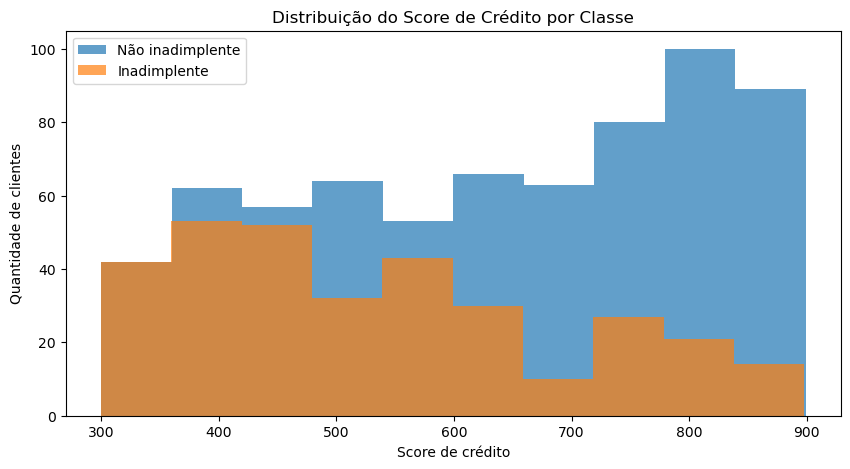

In [14]:
# Distribuição do score de crédito por inadimplência

plt.figure(figsize=(10, 5))

plt.hist(df[df["inadimplente"] == 0]["score_credito"], alpha=0.7, label="Não inadimplente")
plt.hist(df[df["inadimplente"] == 1]["score_credito"], alpha=0.7, label="Inadimplente")

plt.title("Distribuição do Score de Crédito por Classe")
plt.xlabel("Score de crédito")
plt.ylabel("Quantidade de clientes")
plt.legend()
plt.show()

### Interpretação do score de crédito

O gráfico mostra que clientes inadimplentes aparecem com maior frequência nas faixas mais baixas de score de crédito.

Já os clientes não inadimplentes aparecem mais concentrados em scores mais altos.

Esse comportamento faz sentido no contexto de risco de crédito, pois um score menor tende a indicar maior probabilidade de inadimplência.

### Distribuição da renda mensal

A renda mensal pode influenciar a capacidade de pagamento do cliente.

Nesta análise, será observada a distribuição da renda entre clientes inadimplentes e não inadimplentes.

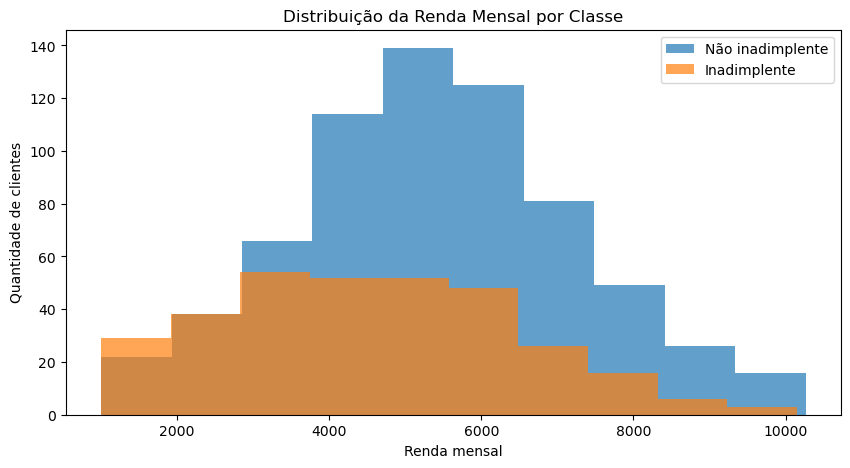

In [16]:
# Distribuição da renda mensal por inadimplência

plt.figure(figsize=(10, 5))

plt.hist(df[df["inadimplente"] == 0]["renda_mensal"], alpha=0.7, label="Não inadimplente")
plt.hist(df[df["inadimplente"] == 1]["renda_mensal"], alpha=0.7, label="Inadimplente")

plt.title("Distribuição da Renda Mensal por Classe")
plt.xlabel("Renda mensal")
plt.ylabel("Quantidade de clientes")
plt.legend()
plt.show()

### Interpretação da renda mensal

O gráfico mostra que clientes inadimplentes aparecem com maior concentração em faixas de renda mais baixas e intermediárias.

Já clientes não inadimplentes aparecem com maior frequência em faixas de renda mais altas.

Essa diferença indica que a renda mensal pode ajudar o modelo a identificar risco de crédito, embora ela não seja suficiente sozinha para separar completamente as classes.

### Relação entre valor do empréstimo e renda

Uma variável importante em análise de risco de crédito é a relação entre o valor do empréstimo solicitado e a renda mensal do cliente.

Quanto maior essa relação, maior pode ser o risco, pois o valor do empréstimo representa um peso maior em relação à capacidade financeira do cliente.

In [18]:
# Criar variável de relação entre empréstimo e renda

df["relacao_emprestimo_renda"] = df["valor_emprestimo"] / df["renda_mensal"]

# Visualizar primeiras linhas
df[["renda_mensal", "valor_emprestimo", "relacao_emprestimo_renda", "inadimplente"]].head()

,renda_mensal,valor_emprestimo,relacao_emprestimo_renda,inadimplente
0,1787.11,27088.75,15.157853,1
1,5406.93,12202.55,2.256835,0
2,3487.30,16572.79,4.752327,1
3,2155.49,21528.14,9.987585,0
4,3706.85,5071.44,1.368127,1


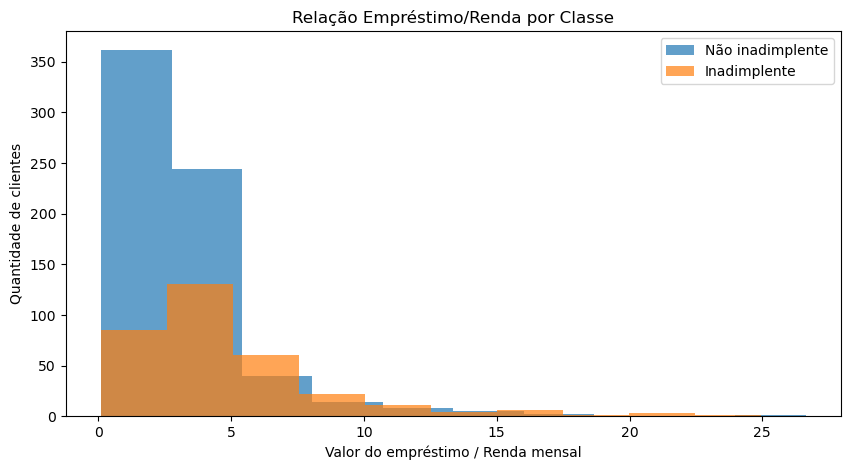

In [19]:
# Distribuição da relação empréstimo/renda por inadimplência

plt.figure(figsize=(10, 5))

plt.hist(df[df["inadimplente"] == 0]["relacao_emprestimo_renda"], alpha=0.7, label="Não inadimplente")
plt.hist(df[df["inadimplente"] == 1]["relacao_emprestimo_renda"], alpha=0.7, label="Inadimplente")

plt.title("Relação Empréstimo/Renda por Classe")
plt.xlabel("Valor do empréstimo / Renda mensal")
plt.ylabel("Quantidade de clientes")
plt.legend()
plt.show()

### Interpretação da relação empréstimo/renda

O gráfico mostra que clientes inadimplentes aparecem com maior frequência em valores mais altos da relação entre empréstimo e renda mensal.

Isso indica que, quando o valor do empréstimo representa um peso maior em relação à renda do cliente, o risco de inadimplência tende a aumentar.

Essa variável é importante para o modelo porque combina duas informações relevantes: capacidade financeira e tamanho da dívida assumida.

Em um contexto real de crédito, essa relação pode ajudar a identificar clientes com maior comprometimento financeiro.

### Histórico de atraso

O histórico de atraso indica se o cliente já apresentou atraso anteriormente.

Essa variável costuma ser muito relevante em modelos de risco de crédito, pois comportamentos anteriores podem indicar maior probabilidade de inadimplência futura.

In [2]:
# Recuperar ambiente após reabrir o notebook

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_PATH = r"E:\Projetos Data science\credit-risk-machine-learning"

DATA_PATH = os.path.join(PROJECT_PATH, "data")
MODELS_PATH = os.path.join(PROJECT_PATH, "models")
NOTEBOOKS_PATH = os.path.join(PROJECT_PATH, "notebooks")
OUTPUTS_PATH = os.path.join(PROJECT_PATH, "outputs")

arquivo_credito = os.path.join(DATA_PATH, "credit_risk_data.csv")

df = pd.read_csv(arquivo_credito)

# Recriar variável criada na análise exploratória
df["relacao_emprestimo_renda"] = df["valor_emprestimo"] / df["renda_mensal"]

print("Dataset carregado com sucesso.")
print(df.shape)

df.head()

Dataset carregado com sucesso.
(1000, 9)


,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,inadimplente,relacao_emprestimo_renda
0,56,1787.11,27088.75,0,382,1,4,1,15.157853
1,69,5406.93,12202.55,0,409,19,6,0,2.256835
2,46,3487.30,16572.79,1,489,19,2,1,4.752327
3,32,2155.49,21528.14,0,550,26,5,0,9.987585
4,60,3706.85,5071.44,1,590,13,5,1,1.368127


In [3]:
# Média de inadimplência por histórico de atraso

inadimplencia_por_atraso = df.groupby("historico_atraso")["inadimplente"].mean() * 100

inadimplencia_por_atraso

historico_atraso
0    12.698413
1    93.442623
Name: inadimplente, dtype: float64

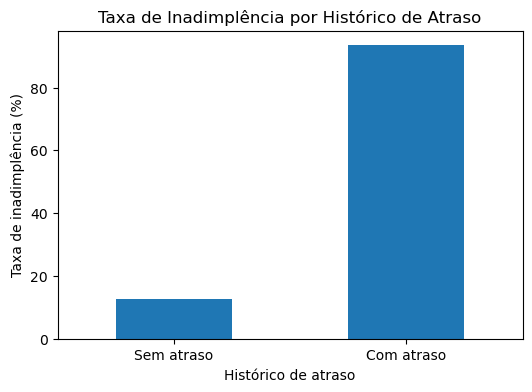

In [4]:
# Gráfico da taxa de inadimplência por histórico de atraso

plt.figure(figsize=(6, 4))

inadimplencia_por_atraso.plot(kind="bar")

plt.title("Taxa de Inadimplência por Histórico de Atraso")
plt.xlabel("Histórico de atraso")
plt.ylabel("Taxa de inadimplência (%)")
plt.xticks(ticks=[0, 1], labels=["Sem atraso", "Com atraso"], rotation=0)
plt.show()

### Interpretação do histórico de atraso

O gráfico mostra uma diferença muito grande na taxa de inadimplência entre clientes com e sem histórico de atraso.

Clientes sem histórico de atraso apresentam uma taxa de inadimplência próxima de 12,7%.

Já clientes com histórico de atraso apresentam uma taxa de inadimplência muito superior, acima de 90%.

Esse resultado indica que o histórico de atraso é uma variável extremamente relevante para prever risco de crédito.

Em um cenário real, essa informação teria grande peso em uma análise de concessão de crédito.

## Matriz de correlação

A matriz de correlação permite analisar a relação entre as variáveis numéricas do dataset.

Nesta etapa, o objetivo é identificar quais variáveis possuem maior relação com a variável alvo `inadimplente`.

In [5]:
# Matriz de correlação

correlacao = df.corr(numeric_only=True)

correlacao

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,inadimplente,relacao_emprestimo_renda
idade,1.000000,0.047178,0.016323,0.014632,-0.023117,-0.028563,0.052629,0.036884,-0.020808
renda_mensal,0.047178,1.000000,-0.038111,-0.028921,0.012004,0.039179,-0.020526,-0.215525,-0.640011
valor_emprestimo,0.016323,-0.038111,1.000000,0.010706,0.030200,-0.009423,-0.000469,0.169508,0.549963
historico_atraso,0.014632,-0.028921,0.010706,1.000000,-0.027380,-0.018966,-0.045920,0.741005,0.014692
score_credito,-0.023117,0.012004,0.030200,-0.027380,1.000000,0.034084,0.031412,-0.265974,0.011064
tempo_emprego_anos,-0.028563,0.039179,-0.009423,-0.018966,0.034084,1.000000,0.027325,-0.051880,0.014075
emprestimos_anteriores,0.052629,-0.020526,-0.000469,-0.045920,0.031412,0.027325,1.000000,-0.056360,0.016503
inadimplente,0.036884,-0.215525,0.169508,0.741005,-0.265974,-0.051880,-0.056360,1.000000,0.253341
relacao_emprestimo_renda,-0.020808,-0.640011,0.549963,0.014692,0.011064,0.014075,0.016503,0.253341,1.000000


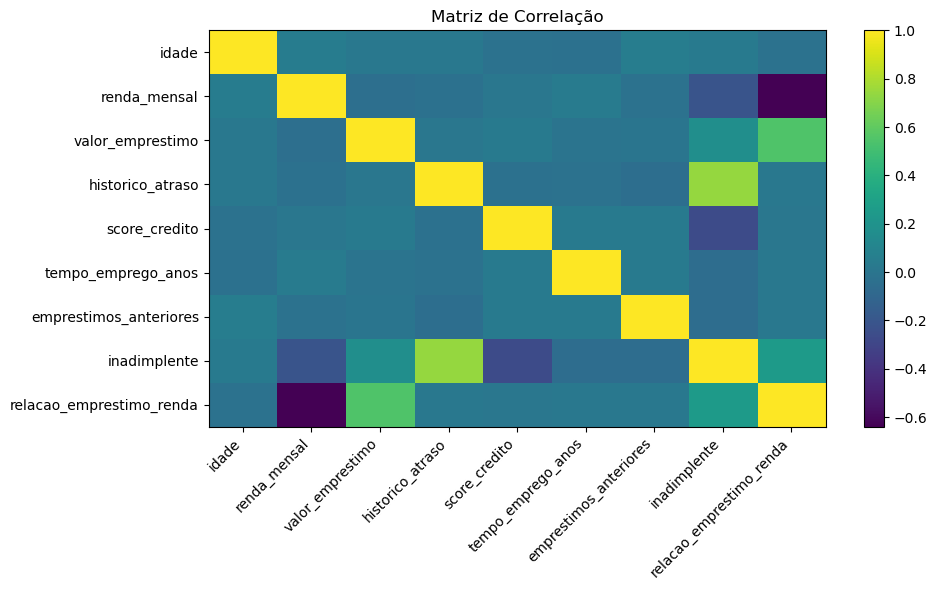

In [6]:
# Gráfico da matriz de correlação

plt.figure(figsize=(10, 6))

plt.imshow(correlacao, aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45, ha="right")
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

### Interpretação da matriz de correlação

A matriz de correlação mostra que algumas variáveis têm relação mais forte com a variável alvo `inadimplente`.

As variáveis mais relevantes observadas foram:

- `historico_atraso`: forte correlação positiva com inadimplência
- `relacao_emprestimo_renda`: correlação positiva com inadimplência
- `valor_emprestimo`: correlação positiva moderada com inadimplência
- `score_credito`: correlação negativa com inadimplência
- `renda_mensal`: correlação negativa com inadimplência

Isso indica que clientes com histórico de atraso, maior valor de empréstimo em relação à renda e menor score de crédito tendem a apresentar maior risco de inadimplência.

Esses resultados fazem sentido no contexto de análise de crédito e ajudam a justificar as variáveis utilizadas no modelo.

## Preparação dos dados para Machine Learning

Nesta etapa, serão separadas as variáveis explicativas e a variável alvo.

A variável alvo será `inadimplente`.

As demais variáveis numéricas serão utilizadas como entrada para os modelos de classificação.

In [8]:
# Definir variáveis explicativas e variável alvo

X = df.drop(columns=["inadimplente"])
y = df["inadimplente"]

print("Variáveis explicativas:", X.shape)
print("Variável alvo:", y.shape)

Variáveis explicativas: (1000, 8)
Variável alvo: (1000,)


In [9]:
# Visualizar variáveis explicativas

X.head()

,idade,renda_mensal,valor_emprestimo,historico_atraso,score_credito,tempo_emprego_anos,emprestimos_anteriores,relacao_emprestimo_renda
0,56,1787.11,27088.75,0,382,1,4,15.157853
1,69,5406.93,12202.55,0,409,19,6,2.256835
2,46,3487.30,16572.79,1,489,19,2,4.752327
3,32,2155.49,21528.14,0,550,26,5,9.987585
4,60,3706.85,5071.44,1,590,13,5,1.368127


In [10]:
# Visualizar variável alvo

y.head()

0    1
1    0
2    1
3    0
4    1
Name: inadimplente, dtype: int64

## Separação entre treino e teste

Nesta etapa, os dados serão divididos em conjuntos de treino e teste.

O conjunto de treino será usado para ensinar o modelo.

O conjunto de teste será usado para avaliar se o modelo consegue generalizar para dados que ele ainda não viu.

Como a variável alvo possui certo desbalanceamento, será usado o parâmetro `stratify=y` para manter a proporção das classes nos conjuntos de treino e teste.

In [11]:
# Separar dados em treino e teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 8)
X_test: (200, 8)
y_train: (800,)
y_test: (200,)


In [12]:
# Verificar distribuição da variável alvo no treino e teste

print("Distribuição no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True) * 100)

Distribuição no treino:
inadimplente
0    67.625
1    32.375
Name: proportion, dtype: float64

Distribuição no teste:
inadimplente
0    67.5
1    32.5
Name: proportion, dtype: float64


## Modelo 1: Logistic Regression

Nesta etapa, será treinado um modelo de Regressão Logística.

Apesar do nome, a Regressão Logística é usada em problemas de classificação.

Neste projeto, ela será usada para prever se um cliente será ou não inadimplente.

### Ajuste de escala para Logistic Regression

A Regressão Logística é sensível à escala das variáveis.

Como o dataset possui variáveis com escalas muito diferentes, será aplicada padronização com `StandardScaler`.

Esse processo transforma as variáveis para uma escala comum, ajudando o modelo a convergir melhor.

In [17]:
# Treinar Logistic Regression com dados padronizados

from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

modelo_lr.fit(X_train_scaled, y_train)

print("Modelo Logistic Regression treinado com sucesso após padronização.")

Modelo Logistic Regression treinado com sucesso após padronização.


In [18]:
# Fazer previsões com Logistic Regression

y_pred_lr = modelo_lr.predict(X_test_scaled)

# Visualizar primeiras previsões
y_pred_lr[:10]

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [19]:
# Avaliação do modelo Logistic Regression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Acurácia Logistic Regression:", round(accuracy_lr, 4))

Acurácia Logistic Regression: 0.92


In [20]:
# Matriz de confusão - Logistic Regression

confusion_matrix(y_test, y_pred_lr)

array([[131,   4],
       [ 12,  53]])

In [21]:
# Relatório de classificação - Logistic Regression

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       135
           1       0.93      0.82      0.87        65

    accuracy                           0.92       200
   macro avg       0.92      0.89      0.91       200
weighted avg       0.92      0.92      0.92       200



### Interpretação da Logistic Regression

O modelo Logistic Regression apresentou bom desempenho geral, com acurácia de 92%.

Na matriz de confusão, o modelo classificou corretamente a maioria dos clientes não inadimplentes e também identificou boa parte dos clientes inadimplentes.

Para a classe 1, que representa os clientes inadimplentes, o modelo obteve precision de 0.93, recall de 0.82 e f1-score de 0.87.

O recall de 0.82 indica que o modelo conseguiu identificar 82% dos clientes inadimplentes, mas ainda deixou alguns casos de risco passarem sem identificação.

Em um problema de risco de crédito, esse ponto é importante, pois falsos negativos podem representar clientes de maior risco sendo aprovados indevidamente.

In [22]:
# Calcular ROC AUC - Logistic Regression

y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("ROC AUC Logistic Regression:", round(roc_auc_lr, 4))

ROC AUC Logistic Regression: 0.9812


### Interpretação do ROC AUC - Logistic Regression

O modelo Logistic Regression apresentou ROC AUC de 0.9812.

Esse resultado indica uma excelente capacidade de separação entre clientes inadimplentes e não inadimplentes.

Quanto mais próximo de 1, melhor a capacidade do modelo em distinguir as classes.

Mesmo com bom desempenho geral, ainda é importante comparar esse resultado com outro modelo, como Random Forest, para verificar se há ganho de performance.

In [23]:
# Treinar modelo Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest Classifier treinado com sucesso.")

Modelo Random Forest Classifier treinado com sucesso.


In [24]:
# Fazer previsões com Random Forest

y_pred_rf = modelo_rf.predict(X_test)

# Visualizar primeiras previsões
y_pred_rf[:10]

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [25]:
# Avaliar Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Acurácia Random Forest:", round(accuracy_rf, 4))

Acurácia Random Forest: 0.955


In [26]:
# Matriz de confusão - Random Forest

confusion_matrix(y_test, y_pred_rf)

array([[129,   6],
       [  3,  62]])

In [27]:
# Relatório de classificação - Random Forest

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       135
           1       0.91      0.95      0.93        65

    accuracy                           0.95       200
   macro avg       0.94      0.95      0.95       200
weighted avg       0.96      0.95      0.96       200



### Interpretação do Random Forest Classifier

O modelo Random Forest Classifier apresentou excelente desempenho geral, com acurácia de 95,5%.

Na matriz de confusão, o modelo identificou corretamente 62 dos 65 clientes inadimplentes no conjunto de teste.

Para a classe 1, que representa os clientes inadimplentes, o modelo obteve precision de 0.91, recall de 0.95 e f1-score de 0.93.

O recall de 0.95 é especialmente importante em um problema de risco de crédito, pois indica que o modelo conseguiu identificar a grande maioria dos clientes com risco de inadimplência.

Comparado à Logistic Regression, o Random Forest reduziu a quantidade de falsos negativos, ou seja, deixou passar menos clientes inadimplentes sem identificação.

In [28]:
# Calcular ROC AUC - Random Forest

y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC AUC Random Forest:", round(roc_auc_rf, 4))

ROC AUC Random Forest: 0.9896


## Comparação dos modelos

Nesta etapa, os modelos treinados serão comparados usando as principais métricas de classificação.

O objetivo é identificar qual modelo apresentou melhor desempenho para previsão de inadimplência.

In [29]:
# Criar tabela comparativa dos modelos

from sklearn.metrics import precision_score, recall_score, f1_score

resultados_modelos = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest Classifier"],
    "Acurácia": [accuracy_lr, accuracy_rf],
    "Precision Classe 1": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall Classe 1": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score Classe 1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [roc_auc_lr, roc_auc_rf]
})

# Arredondar valores
resultados_modelos[["Acurácia", "Precision Classe 1", "Recall Classe 1", "F1-score Classe 1", "ROC AUC"]] = resultados_modelos[
    ["Acurácia", "Precision Classe 1", "Recall Classe 1", "F1-score Classe 1", "ROC AUC"]
].round(4)

resultados_modelos

,Modelo,Acurácia,Precision Classe 1,Recall Classe 1,F1-score Classe 1,ROC AUC
0,Logistic Regression,0.920,0.9298,0.8154,0.8689,0.9812
1,Random Forest Classifier,0.955,0.9118,0.9538,0.9323,0.9896


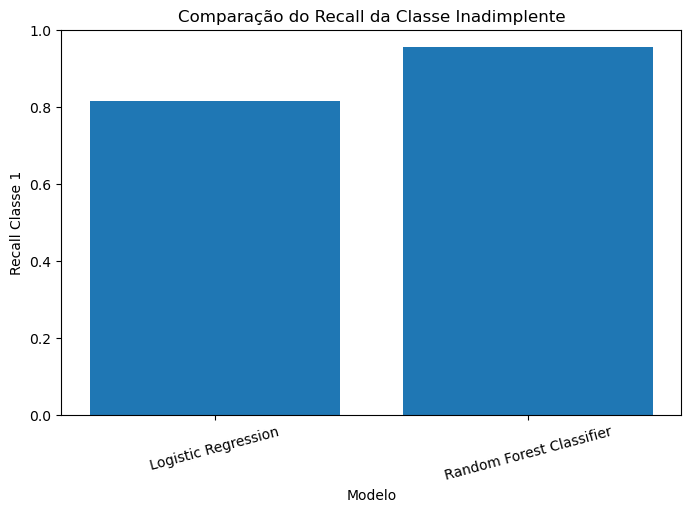

In [30]:
# Gráfico de comparação do Recall da classe inadimplente

plt.figure(figsize=(8, 5))

plt.bar(resultados_modelos["Modelo"], resultados_modelos["Recall Classe 1"])

plt.title("Comparação do Recall da Classe Inadimplente")
plt.xlabel("Modelo")
plt.ylabel("Recall Classe 1")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### Interpretação da comparação dos modelos

A comparação mostra que o Random Forest Classifier apresentou melhor desempenho geral para o problema de risco de crédito.

O principal ganho está no recall da classe 1, que representa os clientes inadimplentes.

Enquanto a Logistic Regression identificou 82% dos clientes inadimplentes, o Random Forest identificou 95%.

Em um problema de risco de crédito, esse resultado é muito importante, pois reduzir falsos negativos significa diminuir a quantidade de clientes inadimplentes que poderiam ser aprovados sem identificação de risco.

Apesar da Logistic Regression também ter apresentado bom desempenho, o Random Forest foi mais eficiente para capturar padrões de risco neste dataset.

In [31]:
# Salvar tabela comparativa dos modelos

csv_resultados = os.path.join(OUTPUTS_PATH, "comparacao_modelos_credito.csv")

resultados_modelos.to_csv(csv_resultados, index=False, encoding="utf-8-sig")

print("Tabela de comparação salva em:")
print(csv_resultados)

Tabela de comparação salva em:
E:\Projetos Data science\credit-risk-machine-learning\outputs\comparacao_modelos_credito.csv


## Salvamento dos resultados

Nesta etapa, os resultados finais dos modelos serão salvos na pasta `outputs`.

Serão salvos:

- arquivo CSV com a comparação dos modelos
- imagem PNG com a tabela comparativa

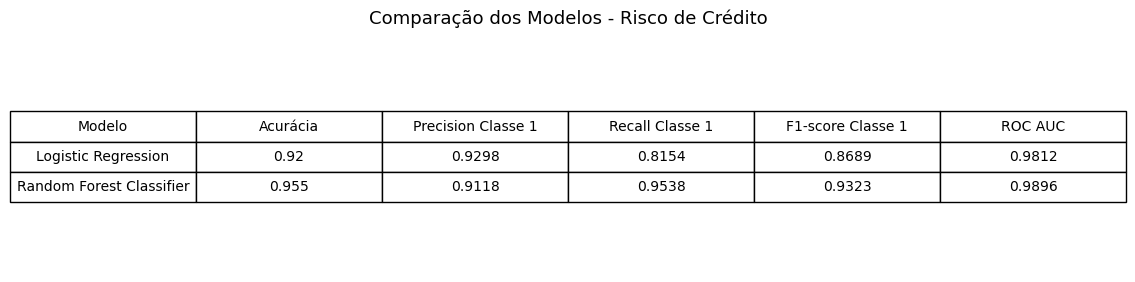

Imagem salva em:
E:\Projetos Data science\credit-risk-machine-learning\outputs\comparacao_modelos_credito.png


In [32]:
# Salvar imagem da tabela comparativa dos modelos

fig, ax = plt.subplots(figsize=(12, 3))

ax.axis("off")

tabela = ax.table(
    cellText=resultados_modelos.values,
    colLabels=resultados_modelos.columns,
    cellLoc="center",
    loc="center"
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8)

plt.title("Comparação dos Modelos - Risco de Crédito", fontsize=13, pad=12)

png_resultados = os.path.join(OUTPUTS_PATH, "comparacao_modelos_credito.png")

plt.savefig(png_resultados, dpi=300, bbox_inches="tight")
plt.show()

print("Imagem salva em:")
print(png_resultados)